# CUDA Embedding Similarity Search

This notebook compiles and runs the accompanying C++/CUDA program, checks every GPU score against CPU references, benchmarks three input sizes, and plots the measured CSV.

Before running: choose **Runtime > Change runtime type > GPU** in Colab. The checks below stop with a clear error if either the NVIDIA GPU tools or CUDA compiler are unavailable; there is no CPU fallback.

In [2]:
import shutil
import subprocess

def run_and_show(command):
    result = subprocess.run(command, text=True, stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT)
    print(result.stdout)
    if result.returncode != 0:
        raise RuntimeError(
            f"Command failed with exit code {result.returncode}: {' '.join(command)}"
        )
    return result

if shutil.which("nvidia-smi") is None:
    raise RuntimeError(
        "nvidia-smi was not found. In Colab, select Runtime > Change runtime type > GPU."
    )
if shutil.which("nvcc") is None:
    raise RuntimeError(
        "nvcc was not found. This runtime does not provide the CUDA compiler."
    )

print("NVIDIA GPU check:")
run_and_show(["nvidia-smi"])
print("CUDA compiler check:")
run_and_show(["nvcc", "--version"])

NVIDIA GPU check:
Wed Sep 30 11:57:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------

CompletedProcess(args=['nvcc', '--version'], returncode=0, stdout='nvcc: NVIDIA (R) Cuda compiler driver\nCopyright (c) 2005-2025 NVIDIA Corporation\nBuilt on Fri_Feb_21_20:23:50_PST_2025\nCuda compilation tools, release 12.8, V12.8.93\nBuild cuda_12.8.r12.8/compiler.35583870_0\n')

## Upload the source

Run the next cell and select `similarity_search.cu` from this project when prompted. If the file is already in the Colab working directory (for example, after cloning or mounting it), the cell uses that copy.

In [3]:
from pathlib import Path

source_path = Path("similarity_search.cu")
if not source_path.exists():
    from google.colab import files
    print("Choose similarity_search.cu from your computer.")
    files.upload()

if not source_path.exists():
    raise FileNotFoundError(
        "similarity_search.cu was not uploaded. Rerun this cell and select the source file."
    )
print(f"Ready to compile {source_path} ({source_path.stat().st_size:,} bytes).")

Choose similarity_search.cu from your computer.


Saving similarity_search.cu to similarity_search.cu
Ready to compile similarity_search.cu (23,145 bytes).


## Compile

Optimization is enabled for meaningful timing while preserving the single-kernel implementation.

In [4]:
run_and_show([
    "nvcc", "-O2", "-std=c++17",
    "similarity_search.cu", "-o", "similarity_search"
])
print("Compilation succeeded.")

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).

Compilation succeeded.


## Run correctness checks and benchmarks

The executable first checks the hand-calculated case and a 1,003-document case, then measures 1,000, 10,000, and 100,000 documents. This cell includes repeated sequential CPU reference measurements in addition to the GPU runs.

In [5]:
run_and_show(["./similarity_search", "--output", "benchmark_results.csv"])

csv_path = Path("benchmark_results.csv")
if not csv_path.exists():
    raise FileNotFoundError("The program finished without creating benchmark_results.csv.")

Using CUDA device: Tesla T4

Correctness checks
  document 0: expected 1.0000000, GPU 1.0000000
  document 1: expected 0.0000000, GPU 0.0000000
  document 2: expected 0.7071068, GPU 0.7071068
  document 3: expected -1.0000000, GPU -1.0000000
  document 4: expected 0.0000000, GPU 0.0000000
  1003-document bounds-check case passed.
  max |GPU - CPU float|  = 0.0000000
  max |GPU - CPU double| = 0.0000001

Benchmarking 1000 documents x 384 dimensions
  Maximum absolute errors across repetitions:
    GPU vs CPU float  = 0.0000000
    GPU vs CPU double = 0.0000001
    CPU float vs CPU double = 0.0000001
  Top five document IDs and scores: (391, 0.1523732) (238, 0.1508413) (675, 0.1419440) (981, 0.1408104) (108, 0.1399421)

Benchmarking 10000 documents x 384 dimensions
  Maximum absolute errors across repetitions:
    GPU vs CPU float  = 0.0000001
    GPU vs CPU double = 0.0000001
    CPU float vs CPU double = 0.0000001
  Top five document IDs and scores: (9897, 0.1941565) (2972, 0.1772131) 

## Inspect results and create the timing chart

Each CSV row is one measured repetition. The chart shows the mean of the five repetitions for each size. Generation, normalization, allocation, validation, top-k, and file output are outside the reported timings. Both axes use logarithmic scales so all three input sizes and timing series remain visible.

,document_count,dimension,repetition,cpu_ms,gpu_kernel_ms,transfer_plus_kernel_ms,max_abs_gpu_vs_cpu_float,max_abs_gpu_vs_cpu_double,max_abs_cpu_float_vs_cpu_double
0,1000,384,1,0.522254,0.145440,0.522564,2.980232e-08,1.005874e-07,1.005874e-07
1,1000,384,2,0.520102,0.146464,0.493903,2.980232e-08,1.005874e-07,1.005874e-07
2,1000,384,3,0.502297,0.145664,0.486954,2.980232e-08,1.005874e-07,1.005874e-07
3,1000,384,4,0.500419,0.145216,0.491499,2.980232e-08,1.005874e-07,1.005874e-07
4,1000,384,5,0.889347,0.147360,0.521731,2.980232e-08,1.005874e-07,1.005874e-07
5,10000,384,1,5.316624,0.260192,3.316911,5.215406e-08,1.375228e-07,1.375228e-07
6,10000,384,2,5.298852,0.258592,3.252418,5.215406e-08,1.375228e-07,1.375228e-07
7,10000,384,3,5.380201,0.257504,3.373967,5.215406e-08,1.375228e-07,1.375228e-07
8,10000,384,4,5.729181,0.259520,3.286460,5.215406e-08,1.375228e-07,1.375228e-07
9,10000,384,5,5.651030,0.259520,3.304771,5.215406e-08,1.375228e-07,1.375228e-07


,document_count,cpu_ms,gpu_kernel_ms,transfer_plus_kernel_ms
0,1000,0.586884,0.146029,0.503330
1,10000,5.475178,0.259066,3.306905
2,100000,59.262880,2.563232,39.484447


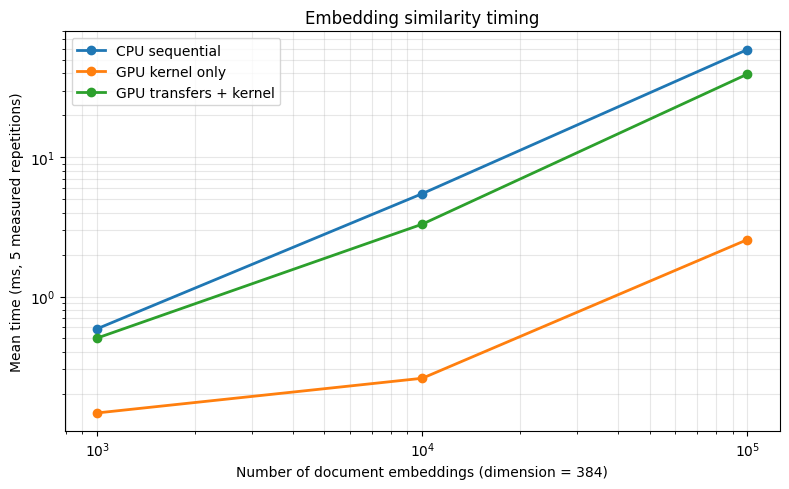

Saved timing_chart.png.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

results = pd.read_csv("benchmark_results.csv")
expected_columns = {
    "document_count", "dimension", "repetition", "cpu_ms",
    "gpu_kernel_ms", "transfer_plus_kernel_ms",
    "max_abs_gpu_vs_cpu_float", "max_abs_gpu_vs_cpu_double",
    "max_abs_cpu_float_vs_cpu_double",
}
missing_columns = expected_columns.difference(results.columns)
if missing_columns:
    raise ValueError(f"CSV is missing columns: {sorted(missing_columns)}")
if len(results) != 15:
    raise ValueError(f"Expected 15 measured rows (3 sizes x 5 repeats), found {len(results)}.")

display(results)
timing_columns = ["cpu_ms", "gpu_kernel_ms", "transfer_plus_kernel_ms"]
mean_timings = results.groupby("document_count", as_index=False)[timing_columns].mean()
display(mean_timings)

fig, ax = plt.subplots(figsize=(8, 5))
for column, label in [
    ("cpu_ms", "CPU sequential"),
    ("gpu_kernel_ms", "GPU kernel only"),
    ("transfer_plus_kernel_ms", "GPU transfers + kernel"),
]:
    ax.plot(mean_timings["document_count"], mean_timings[column],
            marker="o", linewidth=2, label=label)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of document embeddings (dimension = 384)")
ax.set_ylabel("Mean time (ms, 5 measured repetitions)")
ax.set_title("Embedding similarity timing")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig("timing_chart.png", dpi=150)
plt.show()
print("Saved timing_chart.png.")

## Optional: download the measured artifacts

Run this cell if you want the CSV and chart on your computer.

In [7]:
from google.colab import files
files.download("benchmark_results.csv")
files.download("timing_chart.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>